# 01_eda_overview

## Df preparing

In [2]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from IPython.display import display
from sympy import false

np.random.seed(42)
RAW_DIR = "../data/raw"

Upload all tables (except for sample submission, as it is not needed at this stage)

In [3]:
air_reserve_df = pd.read_csv(RAW_DIR + "/air_reserve.csv")
air_store_df = pd.read_csv(RAW_DIR + "/air_store_info.csv")
air_visit_df = pd.read_csv(RAW_DIR + "/air_visit_data.csv")

hpg_reserve_df = pd.read_csv(RAW_DIR + "/hpg_reserve.csv")
hpg_store_df = pd.read_csv(RAW_DIR + "/hpg_store_info.csv")

date_info_df = pd.read_csv(RAW_DIR + "/date_info.csv")
store_id_rel_df = pd.read_csv(RAW_DIR + "/store_id_relation.csv")
sample_submission_df = pd.read_csv(RAW_DIR + "/sample_submission.csv")

Next, need to designate the indexes and convert the dates to the required format.

In [4]:
air_reserve_df["visit_datetime"] = pd.to_datetime(air_reserve_df["visit_datetime"])
air_reserve_df["reserve_datetime"] = pd.to_datetime(air_reserve_df["reserve_datetime"])
air_reserve_df["visit_date"] = pd.to_datetime(air_reserve_df["visit_datetime"].dt.date)
air_reserve_df = air_reserve_df.set_index("visit_date")

air_visit_df["visit_date"] = pd.to_datetime(air_visit_df["visit_date"])
air_visit_df = air_visit_df.set_index("visit_date")

date_info_df["calendar_date"] = pd.to_datetime(date_info_df["calendar_date"])

hpg_reserve_df["visit_datetime"] = pd.to_datetime(hpg_reserve_df["visit_datetime"])
hpg_reserve_df["reserve_datetime"] = pd.to_datetime(hpg_reserve_df["reserve_datetime"])
hpg_reserve_df["visit_date"] = pd.to_datetime(hpg_reserve_df["visit_datetime"].dt.date)
hpg_reserve_df = hpg_reserve_df.set_index("visit_date")

sample_submission_df[['air_store_id', 'visit_date']] = sample_submission_df['id'].str.rsplit('_', n=1, expand=True)
sample_submission_df['visit_date'] = pd.to_datetime(sample_submission_df['visit_date'])

Next, need to split the data by dates in air_reserve_df and hpg_reserve_df (not yet occurred and occurred).

In [5]:
min_sample_date = sample_submission_df["visit_date"].min()

air_res_occurred_df = air_reserve_df[air_reserve_df["visit_datetime"] < min_sample_date]
air_res_target_df = air_reserve_df[air_reserve_df["visit_datetime"] >= min_sample_date]

hpg_res_occured_df = hpg_reserve_df[hpg_reserve_df["visit_datetime"] < min_sample_date]
hpg_res_target_df = hpg_reserve_df[hpg_reserve_df["visit_datetime"] >= min_sample_date]

Let"s determine the number of unique air_store_id's that exist in the corresponding tables.

In [6]:
air_reserve_unique_store_ids = set(air_reserve_df["air_store_id"].unique())
air_visit_unique_store_ids = set(air_visit_df["air_store_id"].unique())
air_store_unique_store_ids = set(air_store_df["air_store_id"].unique())

print(f"Air reserve unique store ids: {len(air_reserve_unique_store_ids)}")
print(f"Air visit unique store ids: {len(air_visit_unique_store_ids)}")
print(f"Air store unique store ids: {len(air_store_unique_store_ids)}")

print(f"Reserve & store ID matches: {len(air_store_unique_store_ids & air_reserve_unique_store_ids)}")
print(f"Visit & store ID matches: {len(air_store_unique_store_ids & air_visit_unique_store_ids)}")

Air reserve unique store ids: 314
Air visit unique store ids: 829
Air store unique store ids: 829
Reserve & store ID matches: 314
Visit & store ID matches: 829


As you can see, the store_info table covers all the ids in the corresponding tables, but there are significantly fewer restaurants with reservation information than restaurants with daily visitor information.

In [7]:
hpg_reserve_unique_store_ids = set(hpg_reserve_df["hpg_store_id"].unique())
hpg_store_unique_store_ids = set(hpg_store_df["hpg_store_id"].unique())

print(f"Hpg reserve unique store ids: {len(hpg_reserve_unique_store_ids)}")
print(f"Hpg store unique store ids: {len(hpg_store_unique_store_ids)}")

print(f"Reserve & store ID matches: {len(hpg_store_unique_store_ids & hpg_reserve_unique_store_ids)}")

Hpg reserve unique store ids: 13325
Hpg store unique store ids: 4690
Reserve & store ID matches: 4690


There are significantly fewer hpg restaurants for which information is available than for which reservations are available.

In [8]:
print("Number of restaurants that have air/hpg compliance: ",
      min(len(set(store_id_rel_df["hpg_store_id"].unique()) & hpg_reserve_unique_store_ids),
          len(set(store_id_rel_df["air_store_id"].unique()) & air_store_unique_store_ids)))

Number of restaurants that have air/hpg compliance:  150


Thus, the restaurant reservation tables (air_reserve, hpg_reserve) initially mixed future and current data. Therefore, they needed to be split into two tables. Some restaurants registered in air_store are not registered in hpg_store.

## Descrbe/info

### Air reserve df

In [9]:
display(air_reserve_df.info())
display(air_reserve_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 92378 entries, 2016-01-01 to 2017-05-31
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   air_store_id      92378 non-null  object        
 1   visit_datetime    92378 non-null  datetime64[ns]
 2   reserve_datetime  92378 non-null  datetime64[ns]
 3   reserve_visitors  92378 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 3.5+ MB


None

,visit_datetime,reserve_datetime,reserve_visitors
count,92378,92378,92378.000000
mean,2016-12-05 08:18:58.751651072,2016-11-27 01:13:07.707030016,4.481749
min,2016-01-01 19:00:00,2016-01-01 01:00:00,1.000000
25%,2016-11-15 19:00:00,2016-11-07 17:00:00,2.000000
50%,2017-01-05 18:00:00,2016-12-27 22:00:00,3.000000
75%,2017-03-03 19:00:00,2017-02-26 18:00:00,5.000000
max,2017-05-31 21:00:00,2017-04-22 23:00:00,100.000000
std,NaN,NaN,4.919669


air_reserve_df has no null values for visitors and dates.

### Air visit df

In [10]:
display(air_visit_df.info())
display(air_visit_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252108 entries, 2016-01-13 to 2017-04-22
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   air_store_id  252108 non-null  object
 1   visitors      252108 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 5.8+ MB


None

,visitors
count,252108.000000
mean,20.973761
std,16.757007
min,1.000000
25%,9.000000
50%,17.000000
75%,29.000000
max,877.000000


air_visit_df has no null values and also has high variability for visitors.

### Air store df

In [11]:
display(air_store_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   air_store_id    829 non-null    object 
 1   air_genre_name  829 non-null    object 
 2   air_area_name   829 non-null    object 
 3   latitude        829 non-null    float64
 4   longitude       829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB


None

### Date info df

In [12]:
display(date_info_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   calendar_date  517 non-null    datetime64[ns]
 1   day_of_week    517 non-null    object        
 2   holiday_flg    517 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 12.2+ KB


None

### Hpg reserve df

In [13]:
display(hpg_reserve_df.info(show_counts=True))
display(hpg_reserve_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2000320 entries, 2016-01-01 to 2017-05-31
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   hpg_store_id      2000320 non-null  object        
 1   visit_datetime    2000320 non-null  datetime64[ns]
 2   reserve_datetime  2000320 non-null  datetime64[ns]
 3   reserve_visitors  2000320 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 76.3+ MB


None

,visit_datetime,reserve_datetime,reserve_visitors
count,2000320,2000320,2.000320e+06
mean,2016-10-15 06:55:20.083586560,2016-10-07 19:57:59.307710464,5.073785e+00
min,2016-01-01 11:00:00,2016-01-01 00:00:00,1.000000e+00
25%,2016-06-26 19:00:00,2016-06-21 12:00:00,2.000000e+00
50%,2016-11-19 20:00:00,2016-11-10 20:00:00,3.000000e+00
75%,2017-02-03 19:00:00,2017-01-27 13:00:00,6.000000e+00
max,2017-05-31 23:00:00,2017-04-22 23:00:00,1.000000e+02
std,NaN,NaN,5.416172e+00


### Hpg store df

In [14]:
display(hpg_store_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hpg_store_id    4690 non-null   object 
 1   hpg_genre_name  4690 non-null   object 
 2   hpg_area_name   4690 non-null   object 
 3   latitude        4690 non-null   float64
 4   longitude       4690 non-null   float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB


None

There are no null values here either.

## Missing values

### Start of restaurant accounting

#### Air visit df

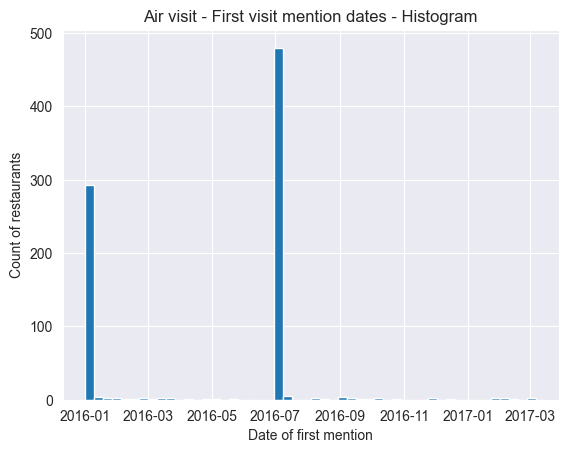

In [15]:
import matplotlib.pyplot as plt

min_dates_plot = air_visit_df.reset_index().groupby("air_store_id")["visit_date"].min().hist(bins=50)
plt.xlabel("Date of first mention")
plt.ylabel("Count of restaurants")
plt.title("Air visit - First visit mention dates - Histogram")
plt.show()

The graph shows that a large number of restaurants did not open immediately (in January 2016), but began somewhat later after the minimum visit date. The month with the highest frequency was July 2016.

#### Air reserve df

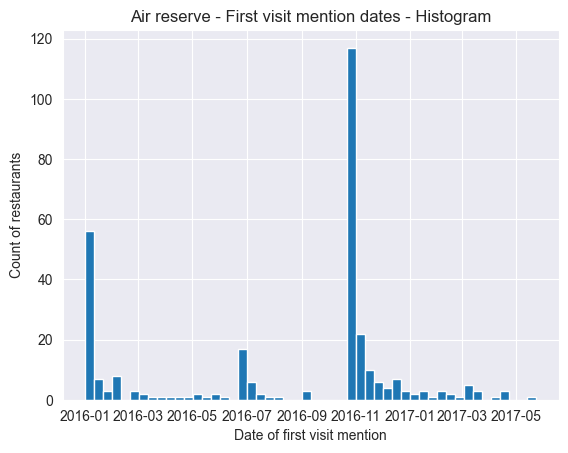

In [16]:
min_dates_plot = air_reserve_df.reset_index().groupby("air_store_id")["visit_date"].min().hist(bins=50)
plt.xlabel("Date of first visit mention")
plt.ylabel("Count of restaurants")
plt.title("Air reserve - First visit mention dates - Histogram")
plt.show()

The graph shows that some restaurants are mentioned for the first time already in the predicted data.

#### Hpg reserve df

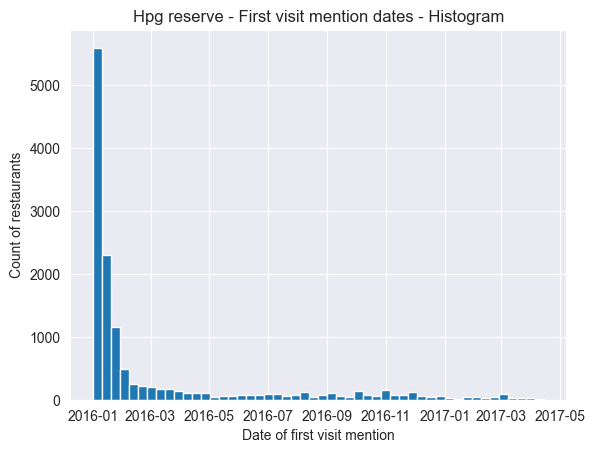

In [17]:
min_dates_plot = hpg_reserve_df.reset_index().groupby("hpg_store_id")["visit_date"].min().hist(bins=50)
plt.xlabel("Date of first visit mention")
plt.ylabel("Count of restaurants")
plt.title("Hpg reserve - First visit mention dates - Histogram")
plt.show()

Most of the restaurants opened early (January 2016), but some still opened later.

### Missing dates

It's necessary to consider the percentage of missed dates for restaurants. However, some restaurants opened later than others, so two cases need to be considered: one with all dates missing, regardless of the opening date, and the other with this factor in.

#### Air visit df

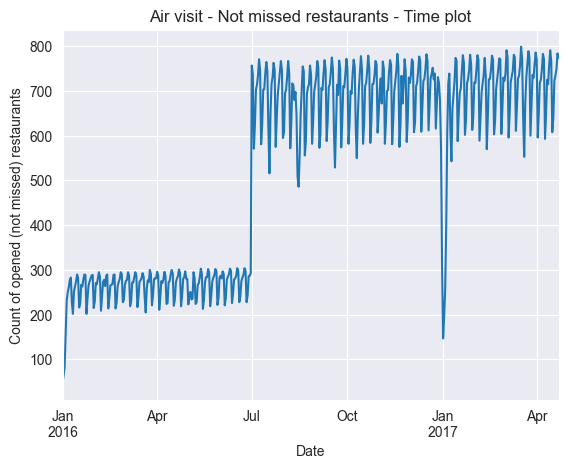

In [49]:
air_visit_df.groupby("visit_date")["air_store_id"].count().plot()
plt.xlabel("Date")
plt.ylabel("Count of opened (not missed) restaurants")
plt.title("Air visit - Not missed restaurants - Time plot")
plt.show()

There is a seasonal pattern in the missing dates. However, July 2016 saw a rise due to the opening (or first mention) of a large number of restaurants. Also in January 2017, a large number of restaurants were missed (there was a decline and rebound).

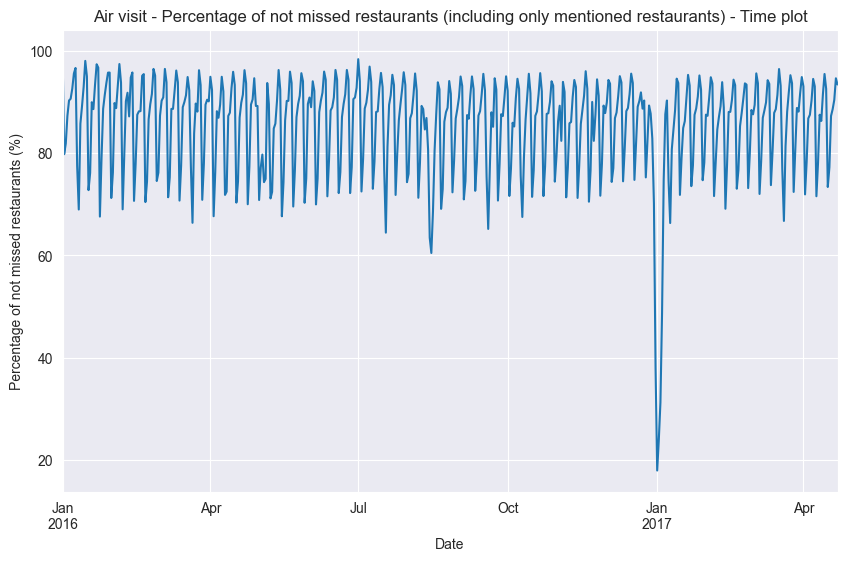

In [69]:
min_dates = air_visit_df.reset_index().groupby("air_store_id")["visit_date"].min()
cumulative_restaurants = min_dates.sort_values().value_counts().sort_index().cumsum()
daily_restaurants = air_visit_df.groupby("visit_date")["air_store_id"].count()
result_df = pd.DataFrame({
    'daily_count': daily_restaurants,
    'total_existing': cumulative_restaurants.reindex(daily_restaurants.index, method='ffill')
})
result_df['percentage'] = (result_df['daily_count'] / result_df['total_existing'] * 100)

plt.figure(figsize=(10, 6))
result_df['percentage'].plot()
plt.xlabel("Date")
plt.ylabel("Percentage of not missed restaurants (%)")
plt.title("Air visit - Percentage of not missed restaurants (including only mentioned restaurants) - Time plot")
plt.grid(True)
plt.show()


The graph shows seasonality in restaurant closures. However, unlike the previous graph, there is no rise in July (due to the number of restaurants not mentioned yet). A decline and rebound is also visible in January 2017.

#### Air reserve df

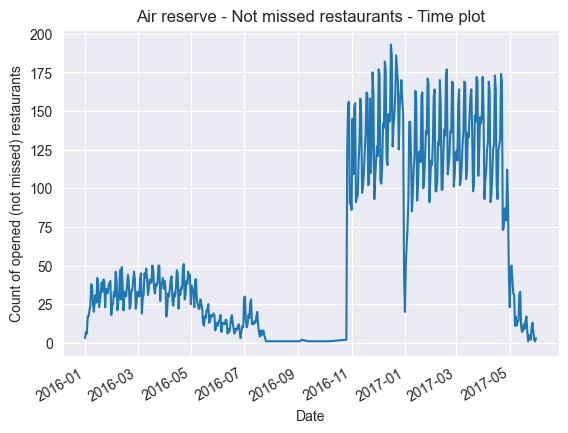

In [67]:
air_res_occurred_df.groupby("visit_date")["air_store_id"].nunique().plot()
plt.xlabel("Date")
plt.ylabel("Count of opened (not missed) restaurants")
plt.title("Air reserve - Not missed restaurants - Time plot")
plt.show()

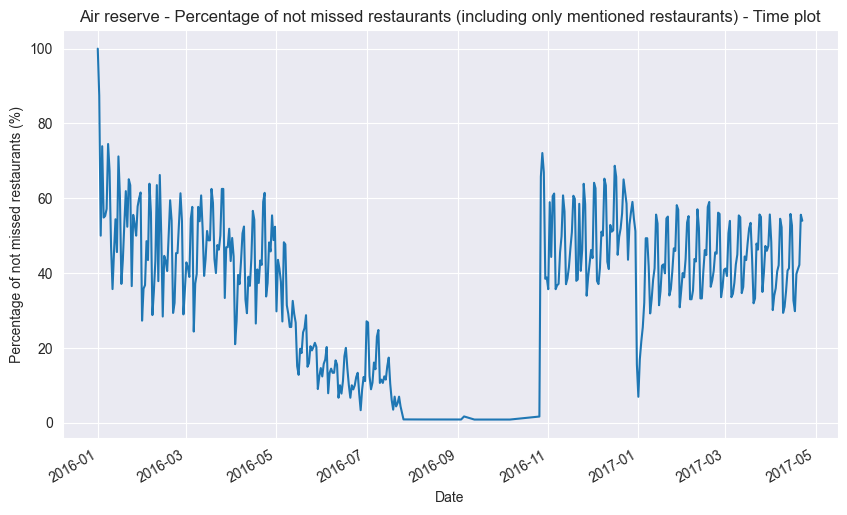

In [70]:
min_dates = air_res_occurred_df.reset_index().groupby("air_store_id")["visit_date"].min()
cumulative_restaurants = min_dates.sort_values().value_counts().sort_index().cumsum()
daily_restaurants = air_res_occurred_df.groupby("visit_date")["air_store_id"].nunique()
result_df = pd.DataFrame({
    'daily_count': daily_restaurants,
    'total_existing': cumulative_restaurants.reindex(daily_restaurants.index, method='ffill')
})
result_df['percentage'] = (result_df['daily_count'] / result_df['total_existing'] * 100)

plt.figure(figsize=(10, 6))
result_df['percentage'].plot()
plt.xlabel("Date")
plt.ylabel("Percentage of not missed restaurants (%)")
plt.title("Air reserve - Percentage of not missed restaurants (including only mentioned restaurants) - Time plot")
plt.grid(True)
plt.show()

Unlike air_visit df, the trend here is not as smooth. There is virtually no data for the period 2016-08 - 2016-10. Some seasonality is observed.

#### Hpg reserve

## Time plots. Distribution. Box plots.

### Air reserve df

It is necessary to consider the distribution of the number of bookings per day (visited), the average number of visitors per day (visited).

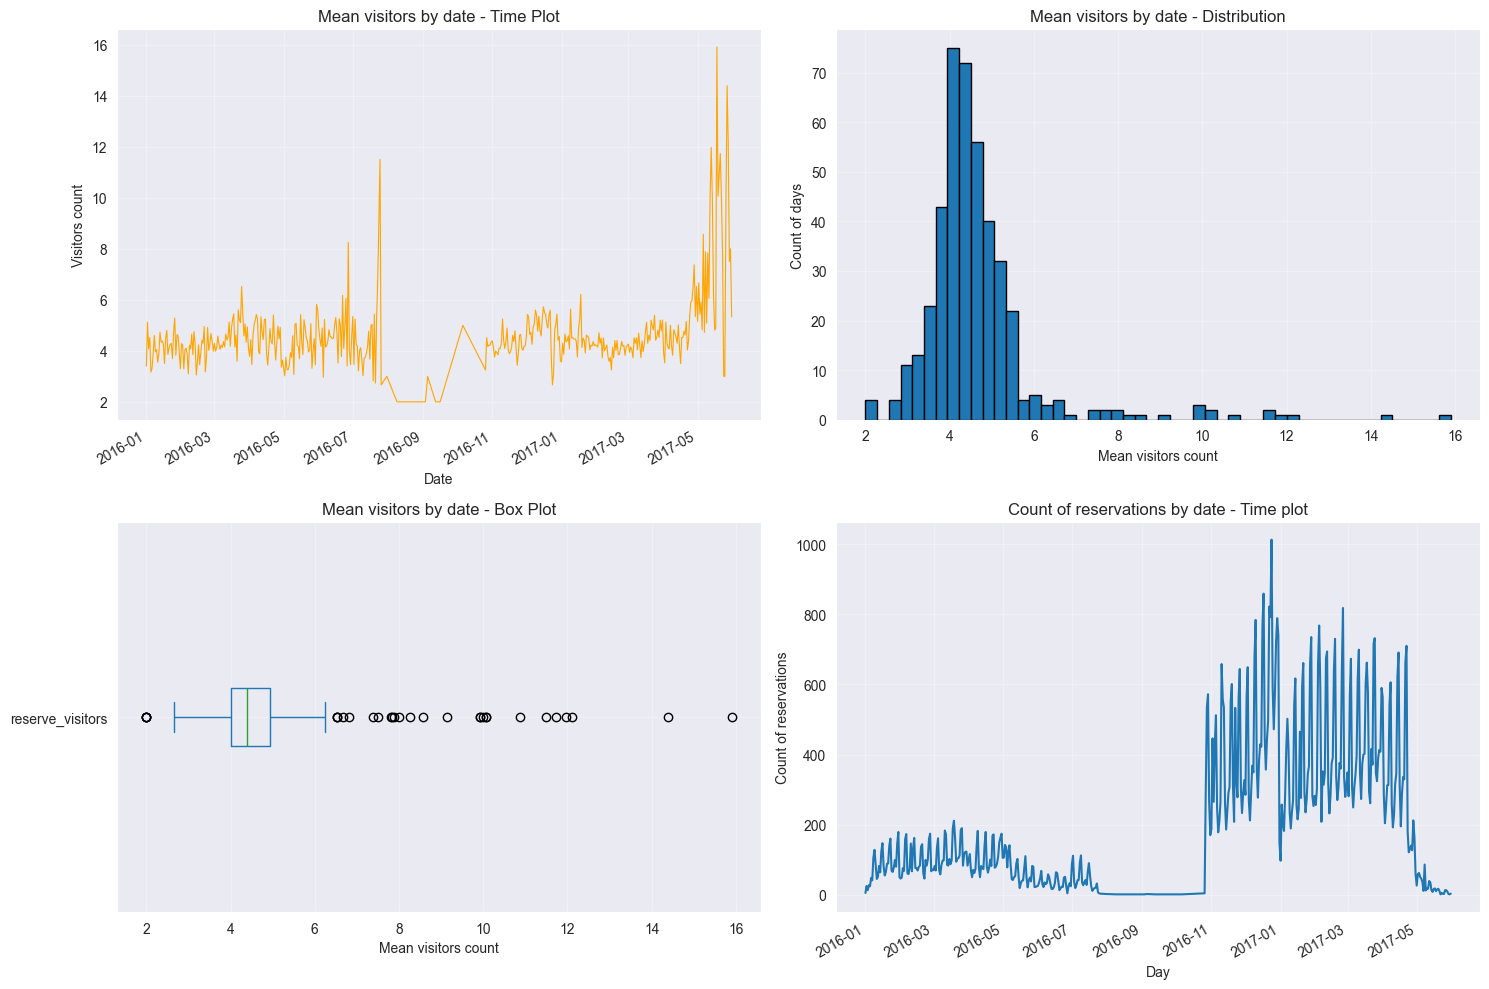

In [21]:
air_reserve_df
plt.figure(figsize=(15, 10))

# Time plot
plt.subplot(2, 2, 1)
air_reserve_df.groupby("visit_date")["reserve_visitors"].mean().plot(linewidth=0.8, color="orange")
plt.title("Mean visitors by date - Time Plot")
plt.xlabel("Date")
plt.ylabel("Visitors count")
plt.grid(True, alpha=0.3)

# Visitors distribution
plt.subplot(2, 2, 2)
air_reserve_df.groupby("visit_date")["reserve_visitors"].mean().hist(bins=50, edgecolor="black")
plt.title("Mean visitors by date - Distribution")
plt.xlabel("Mean visitors count")
plt.ylabel("Count of days")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 3)
air_reserve_df.groupby("visit_date")["reserve_visitors"].mean().plot(kind="box", vert=False)
plt.title("Mean visitors by date - Box Plot")
plt.xlabel("Mean visitors count")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 4)
air_reserve_df.groupby("visit_date")["reserve_visitors"].count().plot()
plt.title("Count of reservations by date - Time plot")
plt.xlabel("Day")
plt.ylabel("Count of reservations")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

Firstly, there are outliers in the data. Secondly, there was a certain period of time during which no bookings were made for the given dates, after which the number increased sharply.

### Air visit df

It is necessary to consider the distribution of visitors for the date, the distribution of visitors for each restaurant, and outliers.

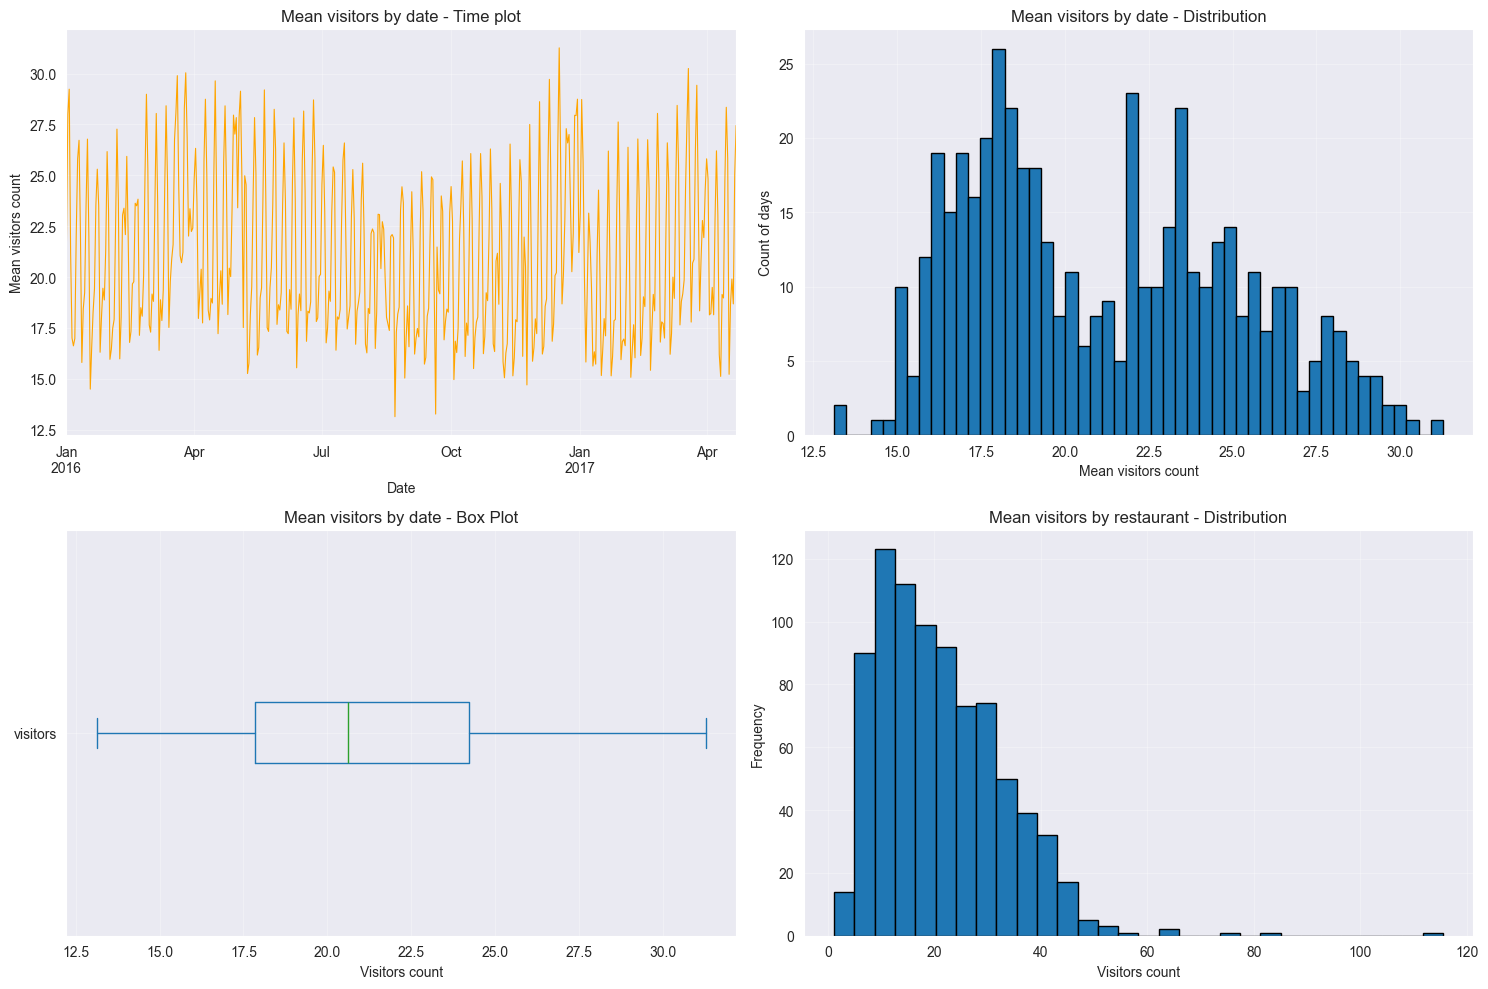

In [22]:
plt.figure(figsize=(15, 10))

# Time plot
plt.subplot(2, 2, 1)
air_visit_df.groupby("visit_date")["visitors"].mean().plot(linewidth=0.8, color="orange")
plt.title("Mean visitors by date - Time plot")
plt.xlabel("Date")
plt.ylabel("Mean visitors count")
plt.grid(True, alpha=0.3)

# Visitors distribution
plt.subplot(2, 2, 2)
air_visit_df.groupby("visit_date")["visitors"].mean().hist(bins=50, edgecolor="black")
plt.title("Mean visitors by date - Distribution")
plt.xlabel("Mean visitors count")
plt.ylabel("Count of days")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 3)
air_visit_df.groupby("visit_date")["visitors"].mean().plot(kind="box", vert=False)
plt.title("Mean visitors by date - Box Plot")
plt.xlabel("Visitors count")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 4)
air_visit_df.groupby("air_store_id")["visitors"].mean().hist(bins=30, edgecolor="black")
plt.title("Mean visitors by restaurant - Distribution")
plt.xlabel("Visitors count")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

There is some periodicity in the data. This will be discussed in more detail later. There are outlier restaurants where the average number of visitors is quite large. The distribution of the average number of visitors by day is possibly multimodal. This may be due to the influence of holidays and non-holidays.

### Hpg reserve

It is necessary to consider the distribution of the number of bookings per day (visited), the average number of visitors per day (visited).

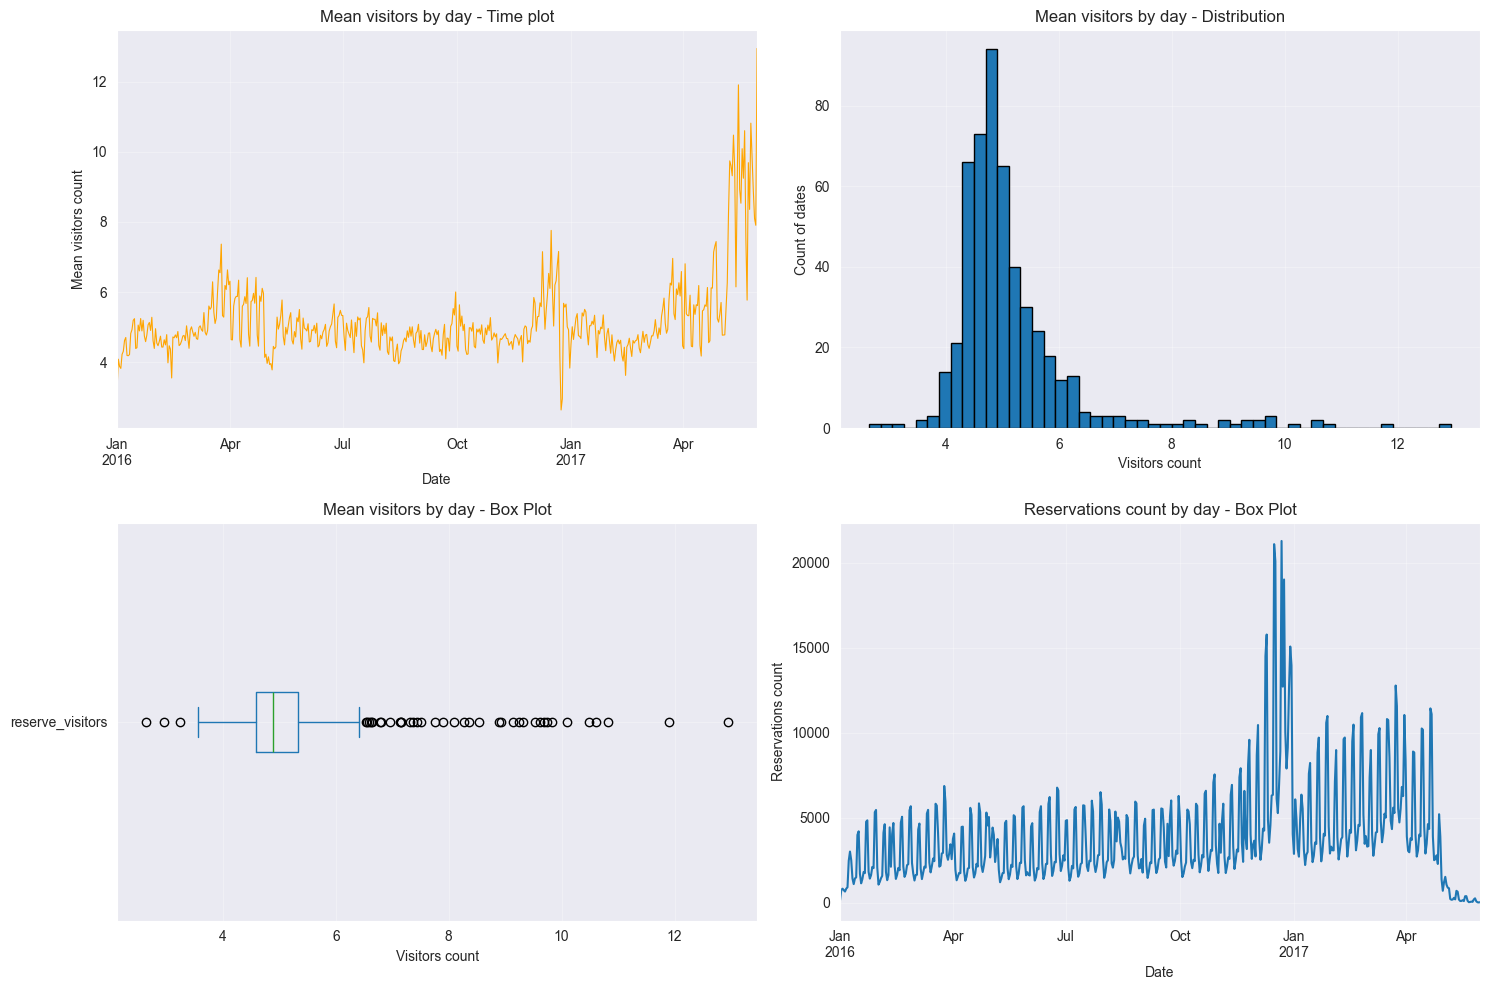

In [23]:
plt.figure(figsize=(15, 10))

# Time plot
plt.subplot(2, 2, 1)
hpg_reserve_df.groupby("visit_date")["reserve_visitors"].mean().plot(linewidth=0.8, color="orange")
plt.title("Mean visitors by day - Time plot")
plt.xlabel("Date")
plt.ylabel("Mean visitors count")
plt.grid(True, alpha=0.3)

# Visitors distribution
plt.subplot(2, 2, 2)
hpg_reserve_df.groupby("visit_date")["reserve_visitors"].mean().hist(bins=50, edgecolor="black")
plt.title("Mean visitors by day - Distribution")
plt.xlabel("Visitors count")
plt.ylabel("Count of dates")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 3)
hpg_reserve_df.groupby("visit_date")["reserve_visitors"].mean().plot(kind="box", vert=False)
plt.title("Mean visitors by day - Box Plot")
plt.xlabel("Visitors count")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 4)
hpg_reserve_df.groupby("visit_date")["reserve_visitors"].count().plot()
plt.title("Reservations count by day - Box Plot")
plt.xlabel("Date")
plt.ylabel("Reservations count")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The box plot shows a significant number of outliers, mostly on the higher side (visitors). The graph of bookings by visit date shows some regularity, but January 2017 shows a significant jump in bookings. Towards the end, the number of bookings becomes small, since the maximum reserve_datetime is one month less than the maximum visit_datetime, and, presumably, most bookings occur for a shorter period.

## Seasonal plots

In [24]:
def add_seasonal_columns(df: pd.DataFrame):
    df["year"] = [x for x in df.index.year]
    df["month"] = [x for x in df.index.month]
    df= df.reset_index()
    df["week"] = df["visit_date"].apply(lambda x:x.week)
    df = df.set_index("visit_date")
    df["day"] = [x for x in df.index.day_of_week]
    df["day_str"] = [x.strftime("%a") for x in df.index]
    df["year_month"] = [str(x.year) + "_" + str(x.month) for x in df.index]

    return df

In [25]:
def plot_seasonal(df: pd.DataFrame, visitors_column_name: str):
    df_plot = (
        df[["month", "day_str", visitors_column_name, "day"]]
        .dropna()
        .groupby(["day_str", "month", "day"])
        .mean()[[visitors_column_name]]
        .reset_index()
    )
    df_plot = df_plot.sort_values(by="day", ascending=True)

    months = df_plot["month"].unique()
    colors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(months), replace=False)

    plt.figure(figsize=(16,12))
    for i, y in enumerate(months):
        if i > 0:
            plt.plot("day_str", visitors_column_name, data=df_plot[df_plot["month"] == y], color=colors[i], label=y)
            plt.text(df_plot.loc[df_plot.month==y, :].shape[0]-.9, df_plot.loc[df_plot.month==y, visitors_column_name][-1:].values[0], y, fontsize=12, color=colors[i])

    plt.gca().set(ylabel= visitors_column_name, xlabel = "Week")
    plt.yticks(fontsize=12, alpha=.7)
    plt.title("Seasonal Plot - Weekly mean visitors", fontsize=20)
    plt.show()

In [26]:
def plot_last_month(df, month: int, visitors_column_name: str):
    min_date = df.index.min()
    max_allowed_date = min_date + pd.DateOffset(months=month)
    df.loc[(df.index <= max_allowed_date)].groupby("visit_date")[visitors_column_name].quantile(0.95).plot(
        title="Visitors for 3 month - Time Plot (95 quantile)", figsize=(10, 6), color="orange")

    plt.ylabel("Visitors")
    plt.xlabel("Date")
    plt.grid(alpha=0.3)
    plt.show()

### Hpg reserve df

It is necessary to research count of bookings depending on the day of the week and the month.

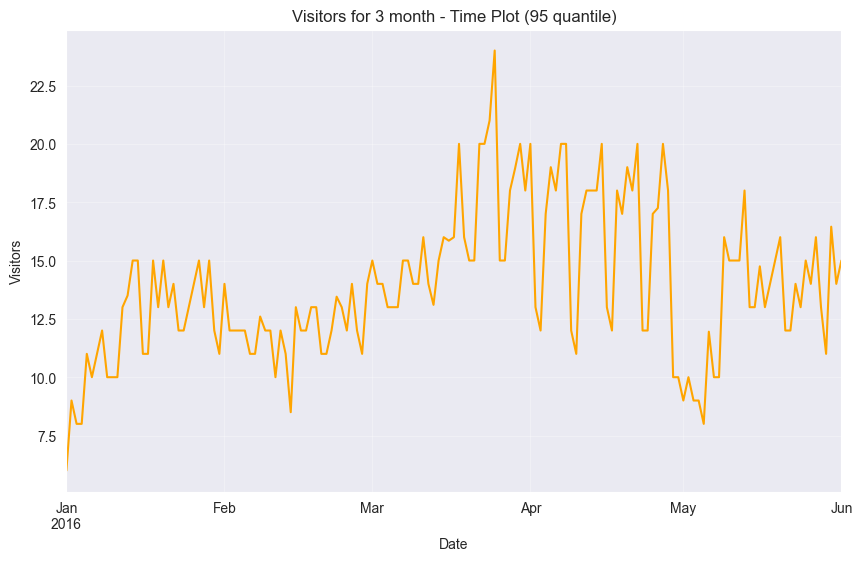

In [27]:
plot_last_month(hpg_reserve_df, 5, "reserve_visitors")

There is no seasonality or trend on the graph.

In [28]:
hpg_reserve_seasonal_df = add_seasonal_columns(hpg_reserve_df)

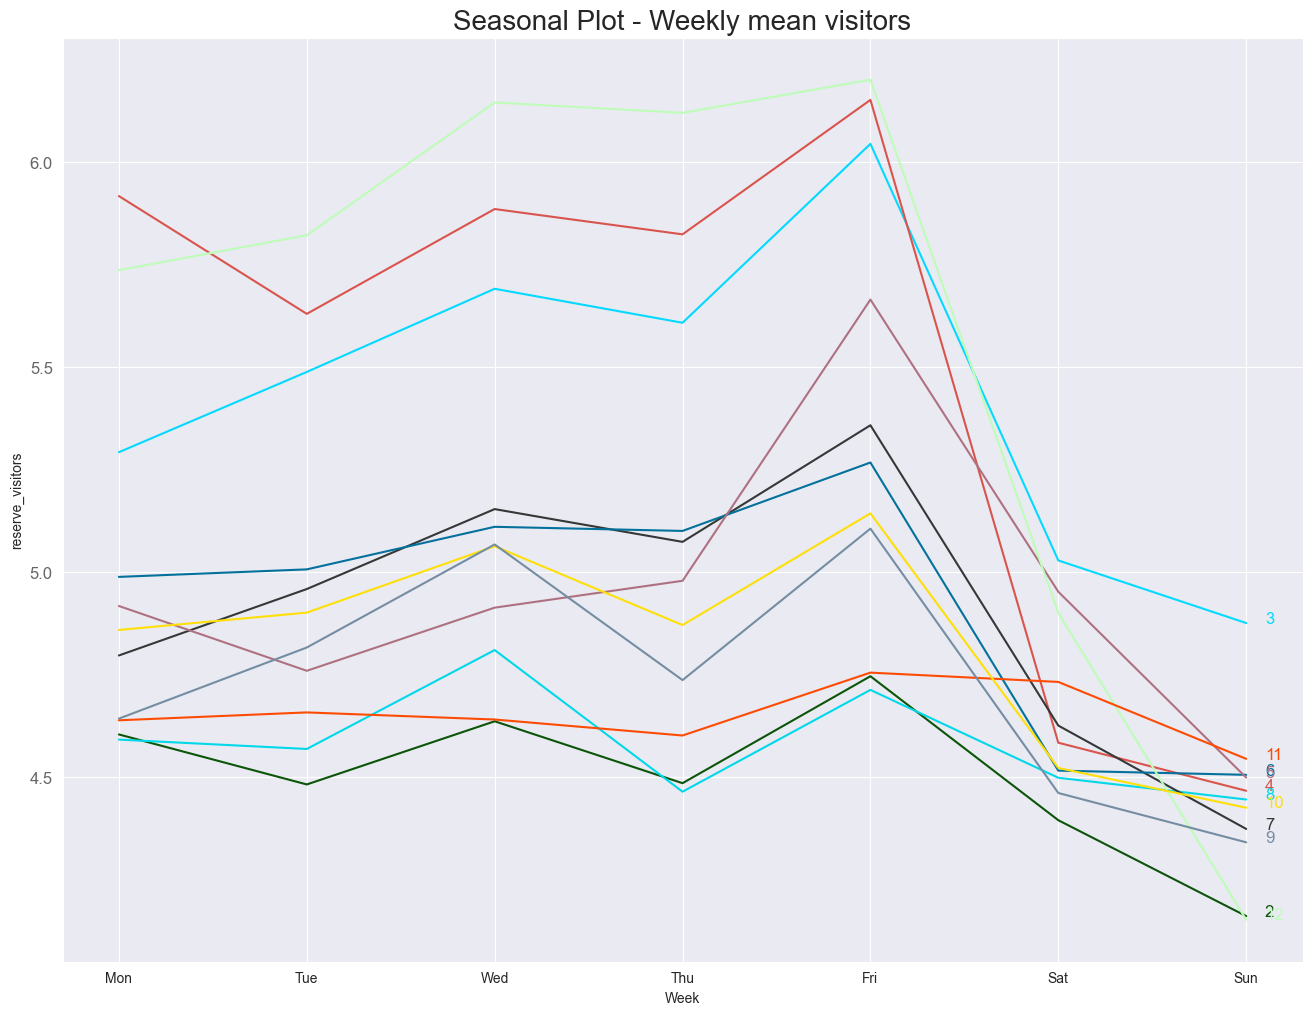

In [29]:
plot_seasonal(hpg_reserve_seasonal_df, "reserve_visitors")

### Air reserve df

It is necessary to research count of bookings depending on the day of the week and the month.

In [30]:
air_reserve_seasonal_df = add_seasonal_columns(air_reserve_df)

### Air visit data

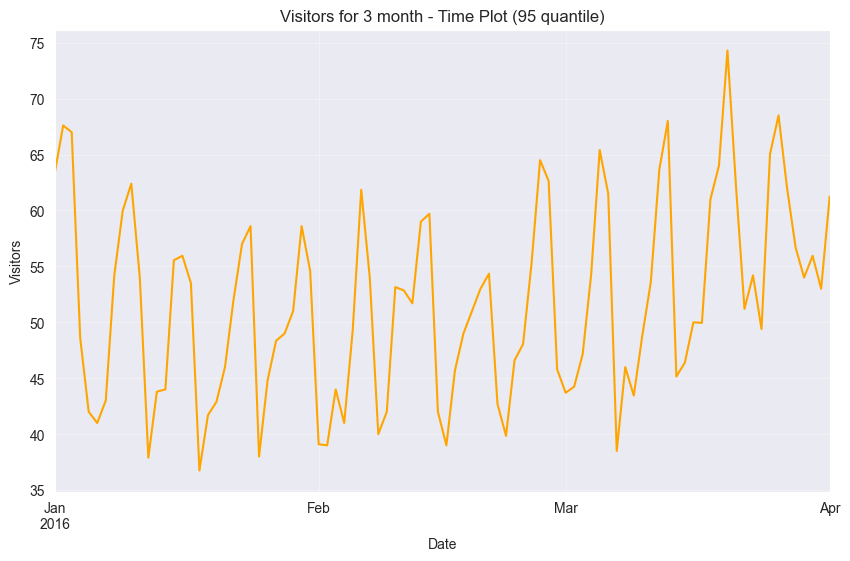

In [31]:
plot_last_month(air_visit_df, 3, "visitors")

We see a periodicity on the graph. It"s most likely related to the weekend.

In [32]:
air_visit_seasonal_df = add_seasonal_columns(air_visit_df)

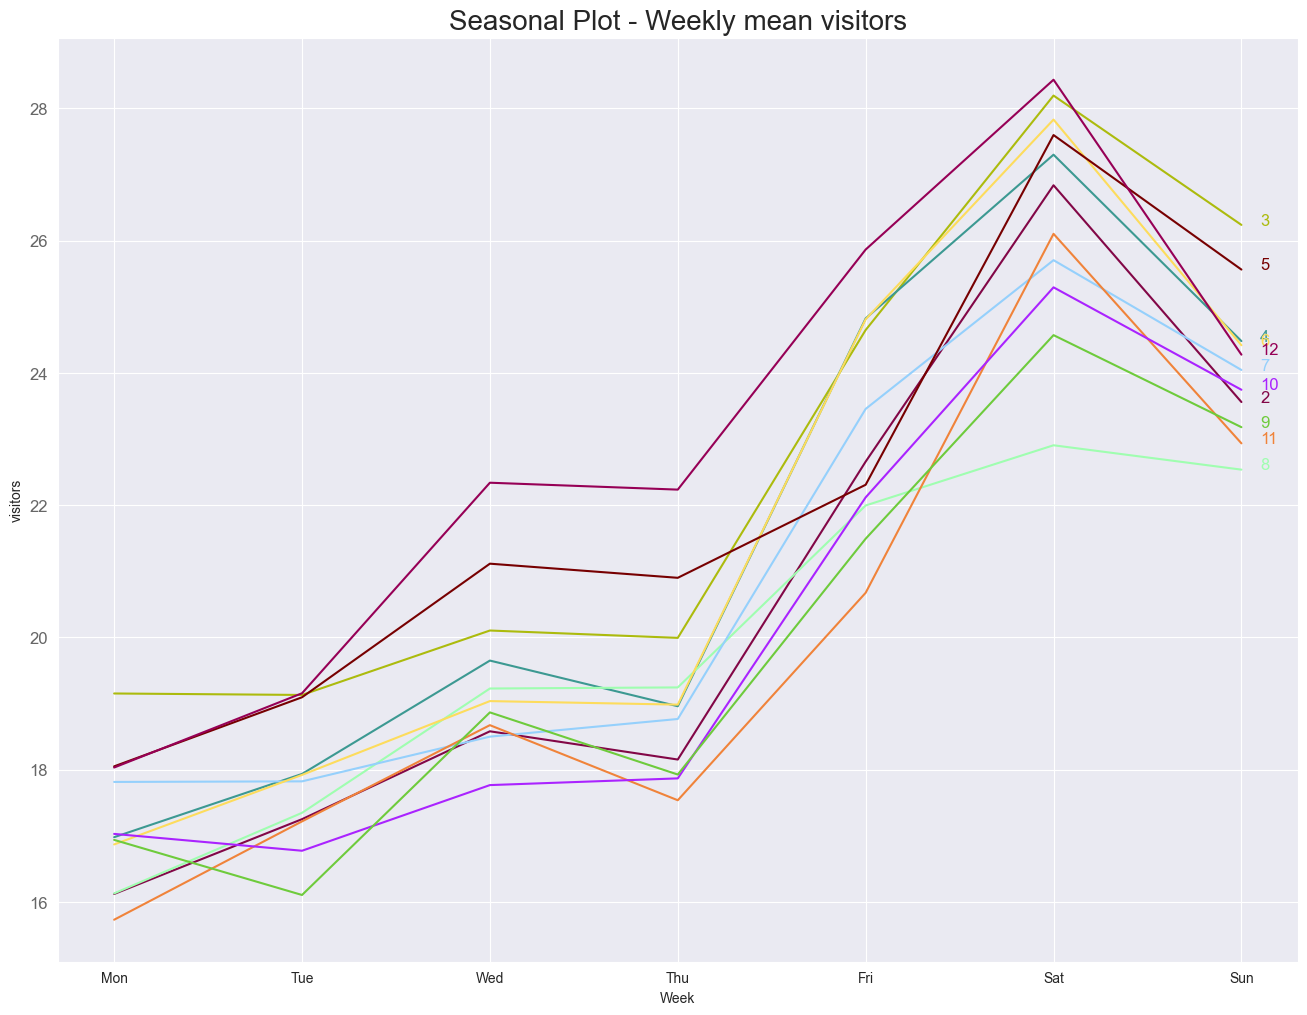

In [33]:
plot_seasonal(air_visit_seasonal_df, "visitors")

The busiest hours are Friday through Sunday (and especially Saturday). There"s some slight fluctuation by month, but the trend remains consistent.

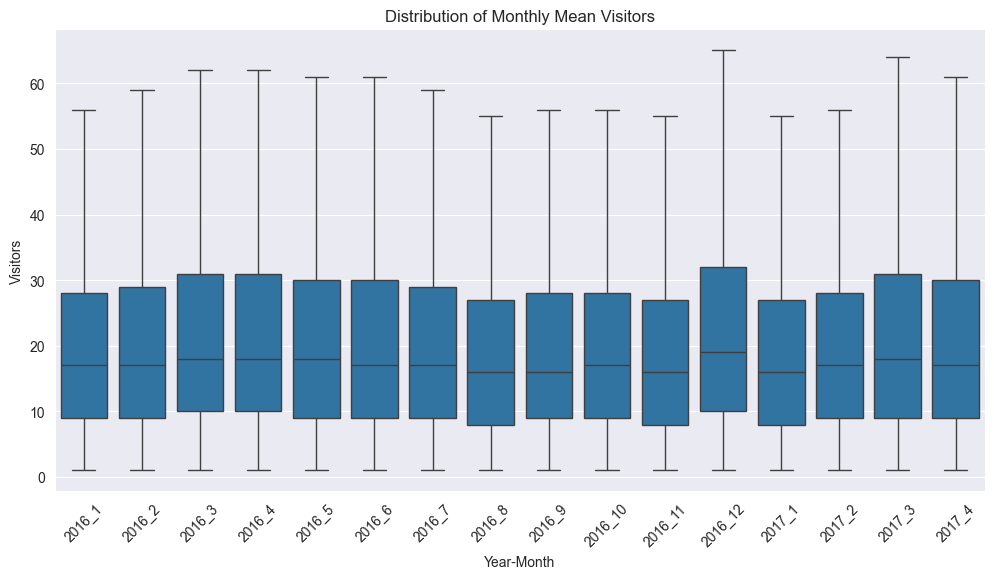

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='year_month', y='visitors', data=air_visit_seasonal_df, showfliers=False)
plt.title('Distribution of Monthly Mean Visitors')
plt.xlabel('Year-Month')
plt.ylabel('Visitors')
plt.xticks(rotation=45)
plt.show()

The graph shows that the monthly average remains virtually unchanged, except for December, when demand increases.

### Data Correlation

It is necessary to investigate the dependence of visits on the day of the week, on holidays, on the next day (holiday, weekend or working day), on the area to which the store belongs, on the genre. Visitors on some holiday by genre.

Tasks:

Missing:

Create a distribution for each table (reservations and visits) of the number of closed restaurants (as a percentage of those already mentioned) by days.
Create a distribution for reserve_date - if reservations were made on that day of the week, they came more often/later.
Perform everything described in the docs.
And then...

## Conclusion

Thus, the restaurant reservation tables (air_reserve, hpg_reserve) initially mixed future and current data. Therefore, they needed to be split into two tables. Some restaurants registered in air_store are not registered in hpg_store.

There are no null values in the data, but there are missing rows on certain dates for certain restaurants.

In the air_visit df a large number of restaurants did not open immediately (in January 2016), but began somewhat later after the minimum visit date. The month with the highest frequency was July 2016. Some restaurants are mentioned for the first time already in the predicted data in air_reserve df. In hpg_reserve df most of the restaurants first mentioned early (January 2016), but some still mentioned later.

There is seasonality in restaurant closures in air_visit df. A decline and rebound is visible in January 2017. For air_reserve df, unlike air_visit df, the trend is not as smooth. There is virtually no data for the period 2016-08 - 2016-10. Some seasonality is observed.